# 000978 — data sanity checks (streamed, one session)

Streamed QC for DANDI dandiset **000978** ("Single Day W-Track Learning"):
CA1+PFC, one file per animal, **17 epochs alternating sleep / W-track run**
across a single day. Analyzed in parallel with 000447 — never merged.

Run vs. sleep is identified by the `trials` table (run epochs contain W-track
trials; sleep epochs contain none). Checks:
1. Epoch structure classified run/sleep; unit counts by region
2. Spike raster over the whole day, split by region, run epochs shaded
3. Mean firing rate by region, run vs. sleep
4. Behavior: W-track trajectory per run session vs. a sleep-box epoch
5. **Learning curve** — fraction correct across the 8 run sessions


## Setup

In [1]:
import sys, pathlib
_root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "common" / "config.py").exists())
for _d in ("common", "000978"):
    sys.path.insert(0, str(_root / "src" / _d))
from importlib import import_module
import numpy as np, pandas as pd, matplotlib.pyplot as plt
dl = import_module("download")
DANDISET = "000978"
REGION_COLOR = {"CA1": "tab:blue", "PFC": "tab:red"}
plt.rcParams["figure.figsize"] = (10, 4); plt.rcParams["figure.dpi"] = 100

## Pick a session and lazily load what we need

In [2]:
assets = [p for p in dl.list_asset_paths(dandiset_id=DANDISET) if p.endswith(".nwb")]
for i, p in enumerate(assets): print(i, p)
SESSION = assets[0]   # change index for another animal
SESSION

A newer version (0.76.7) of dandi/dandi-cli is available. You are using 0.75.1


0 sub-JDS-SingleDay-JS14/sub-JDS-SingleDay-JS14_behavior+ecephys.nwb
1 sub-JDS-SingleDay-ER1/sub-JDS-SingleDay-ER1_behavior+ecephys.nwb
2 sub-JDS-SingleDay-JS21/sub-JDS-SingleDay-JS21_behavior+ecephys.nwb
3 sub-JDS-SingleDay-JS15/sub-JDS-SingleDay-JS15_behavior+ecephys.nwb
4 sub-JDS-SingleDay-JS17/sub-JDS-SingleDay-JS17_behavior+ecephys.nwb
5 sub-JDS-SingleDay-KL8/sub-JDS-SingleDay-KL8_behavior+ecephys.nwb
6 sub-JDS-SingleDay-JS34/sub-JDS-SingleDay-JS34_behavior+ecephys.nwb
7 sub-JDS-SingleDay-ZT2/sub-JDS-SingleDay-ZT2_obj-u40err_behavior+ecephys.nwb
8 sub-JDS-SingleDay-ZT2/sub-JDS-SingleDay-ZT2_obj-1dss6zi_behavior+ecephys.nwb


'sub-JDS-SingleDay-JS14/sub-JDS-SingleDay-JS14_behavior+ecephys.nwb'

In [3]:
with dl.stream_nwb(SESSION, dandiset_id=DANDISET) as nwb:
    subject = getattr(nwb.subject, "subject_id", None)
    epochs = nwb.intervals["epoch intervals"].to_dataframe().reset_index(drop=True)[["start_time", "stop_time"]]
    trials = nwb.intervals["trials"].to_dataframe()

    n_units = len(nwb.units)
    unit_region = np.array([nwb.units["electrodes"][i]["location"].unique()[0] for i in range(n_units)], dtype=object)
    spike_times = [np.asarray(nwb.units["spike_times"][i]) for i in range(n_units)]

    ss = nwb.processing["behavior"].data_interfaces["Position"].spatial_series["SpatialSeries"]
    pos_t = np.asarray(ss.timestamps[:]); pos = np.asarray(ss.data[:])

# classify epochs by trial overlap (run = has trials)
tr_start = trials["start_time"].to_numpy()
epochs["n_trials"] = [(int(((tr_start >= r.start_time) & (tr_start < r.stop_time)).sum())) for r in epochs.itertuples()]
epochs["kind"] = np.where(epochs["n_trials"] > 0, "run", "sleep")
epochs["run_session"] = np.where(epochs.kind == "run", epochs.kind.eq("run").cumsum(), -1)
print(f"subject {subject}: {n_units} units "
      f"(CA1={np.sum(unit_region=='CA1')}, PFC={np.sum(unit_region=='PFC')})")
print(f"{(epochs.kind=='run').sum()} run + {(epochs.kind=='sleep').sum()} sleep epochs; {len(trials)} trials")
epochs

subject JDS-SingleDay-JS14: 72 units (CA1=31, PFC=41)
8 run + 9 sleep epochs; 298 trials


,start_time,stop_time,n_trials,kind,run_session
0,167.580733,1420.149133,0,sleep,-1
1,1614.809133,2536.896767,25,run,1
2,2630.941767,3595.240000,0,sleep,-1
3,3726.469733,4645.338633,30,run,2
4,4780.204067,5853.121133,0,sleep,-1
5,5970.043333,6923.783033,41,run,3
6,7024.089700,8028.563300,0,sleep,-1
7,8112.009300,9037.396733,45,run,4
8,9131.842567,10345.611133,0,sleep,-1
9,10441.577067,11345.971200,43,run,5


## 1. Spike raster over the whole day
Units grouped by region (blue=CA1, red=PFC). Green bands = run (W-track) epochs.

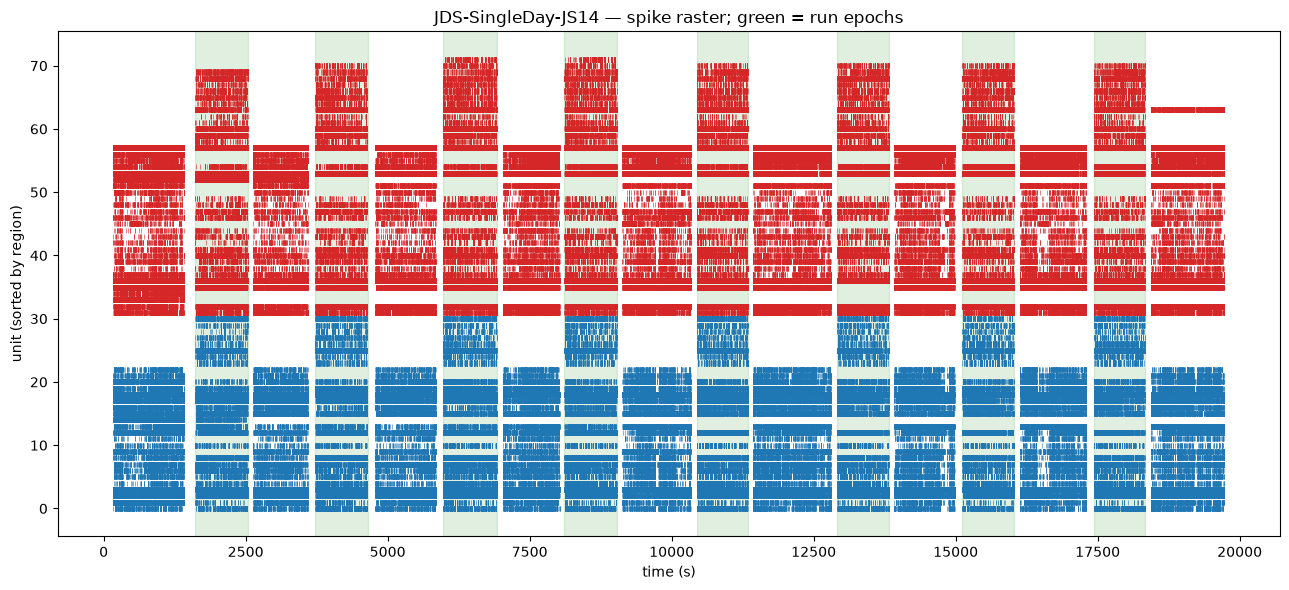

In [4]:
order = np.argsort(unit_region, kind="stable")
colors = [REGION_COLOR.get(unit_region[i], "gray") for i in order]
fig, ax = plt.subplots(figsize=(13, 6))
ax.eventplot([spike_times[i] for i in order], colors=colors, linewidths=0.4, linelengths=0.8)
for r in epochs.itertuples():
    if r.kind == "run":
        ax.axvspan(r.start_time, r.stop_time, color="green", alpha=0.12)
ax.set_xlabel("time (s)"); ax.set_ylabel("unit (sorted by region)")
ax.set_title(f"{subject} — spike raster; green = run epochs")
plt.tight_layout()

## 2. Mean firing rate by region, run vs. sleep

median Hz  CA1 run/sleep: 0.72 0.51 | PFC: 0.51 0.24


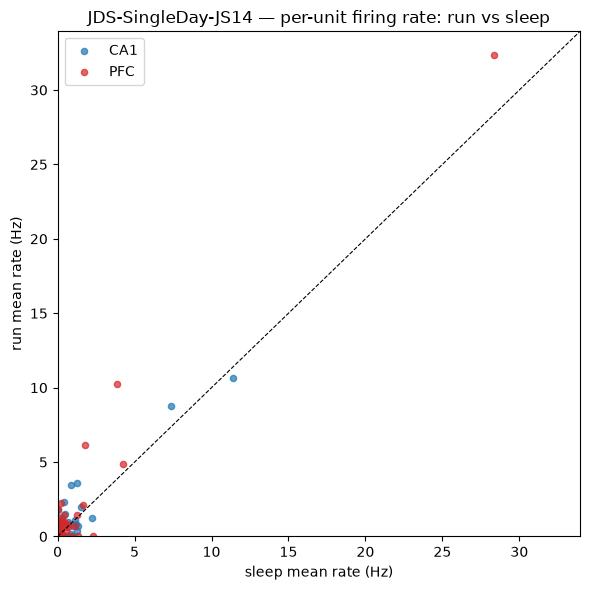

In [5]:
def rate_in(mask_epochs):
    total = 0.0; dur = 0.0
    wins = epochs[epochs.kind.isin(mask_epochs)] if isinstance(mask_epochs, list) else epochs[epochs.kind == mask_epochs]
    rates = np.zeros(n_units)
    for r in wins.itertuples():
        dur += r.stop_time - r.start_time
        for u, st in enumerate(spike_times):
            rates[u] += ((st >= r.start_time) & (st < r.stop_time)).sum()
    return rates / max(dur, 1e-9)

run_hz, sleep_hz = rate_in("run"), rate_in("sleep")
fig, ax = plt.subplots(figsize=(6, 6))
for reg in ["CA1", "PFC"]:
    m = unit_region == reg
    ax.scatter(sleep_hz[m], run_hz[m], s=20, alpha=0.7, color=REGION_COLOR[reg], label=reg)
lim = [0, max(run_hz.max(), sleep_hz.max()) * 1.05]
ax.plot(lim, lim, "k--", lw=0.8); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("sleep mean rate (Hz)"); ax.set_ylabel("run mean rate (Hz)"); ax.legend()
ax.set_title(f"{subject} — per-unit firing rate: run vs sleep")
plt.tight_layout()
print("median Hz  CA1 run/sleep:", round(np.median(run_hz[unit_region=='CA1']),2),
      round(np.median(sleep_hz[unit_region=='CA1']),2),
      "| PFC:", round(np.median(run_hz[unit_region=='PFC']),2),
      round(np.median(sleep_hz[unit_region=='PFC']),2))

## 3. Behavior: W-track runs vs. a sleep epoch

Each run session's trajectory should show the W maze; a sleep epoch should be a
tight rest-box blob — confirming the run/sleep labels are correct.

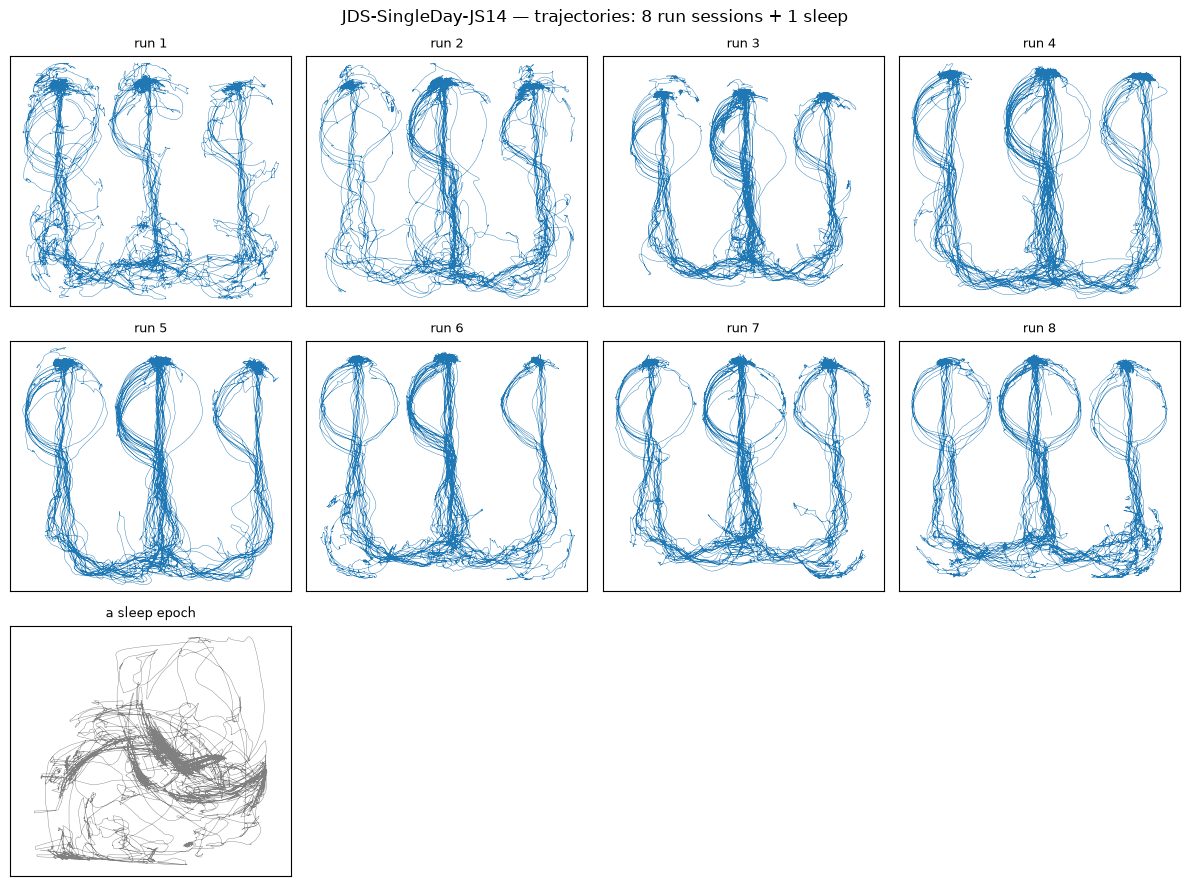

In [6]:
run_eps = epochs[epochs.kind == "run"]
ncol = 4; nrow = int(np.ceil((len(run_eps) + 1) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3 * ncol, 3 * nrow))
axes = axes.ravel()
for k, r in enumerate(run_eps.itertuples()):
    m = (pos_t >= r.start_time) & (pos_t < r.stop_time)
    axes[k].plot(pos[m, 0], pos[m, 1], lw=0.3)
    axes[k].set_title(f"run {int(r.run_session)}", fontsize=9)
    axes[k].set_aspect("equal", adjustable="datalim"); axes[k].set_xticks([]); axes[k].set_yticks([])
# one sleep epoch for contrast
sr = epochs[epochs.kind == "sleep"].iloc[0]
m = (pos_t >= sr.start_time) & (pos_t < sr.stop_time)
axes[len(run_eps)].plot(pos[m, 0], pos[m, 1], lw=0.3, color="gray")
axes[len(run_eps)].set_title("a sleep epoch", fontsize=9)
axes[len(run_eps)].set_aspect("equal", adjustable="datalim"); axes[len(run_eps)].set_xticks([]); axes[len(run_eps)].set_yticks([])
for j in range(len(run_eps) + 1, len(axes)): axes[j].axis("off")
fig.suptitle(f"{subject} — trajectories: {len(run_eps)} run sessions + 1 sleep")
plt.tight_layout()

## 4. Learning curve across the day

Fraction of correct trials per run session — the behavioral signature of
single-day W-track learning that motivates the session-sequence analysis.

,mean,count
run_session,,
1,0.440000,25
2,0.800000,30
3,0.975610,41
4,0.911111,45
5,0.883721,43
6,0.947368,38
7,0.921053,38
8,0.868421,38


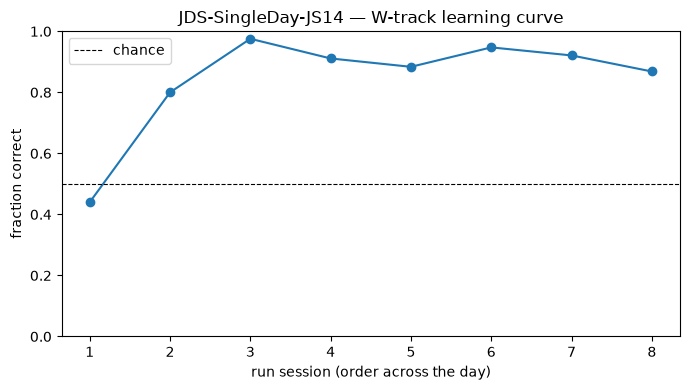

In [7]:
trials = trials.copy()
def which_run(t):
    hit = epochs[(epochs.kind == "run") & (epochs.start_time <= t) & (t < epochs.stop_time)]
    return int(hit.run_session.iloc[0]) if len(hit) else -1
trials["run_session"] = trials["start_time"].map(which_run)
perf = trials[trials.run_session > 0].groupby("run_session")["correct"].agg(["mean", "count"])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(perf.index, perf["mean"], "o-")
ax.axhline(0.5, color="k", ls="--", lw=0.8, label="chance")
ax.set_xlabel("run session (order across the day)"); ax.set_ylabel("fraction correct")
ax.set_ylim(0, 1); ax.set_title(f"{subject} — W-track learning curve"); ax.legend()
plt.tight_layout()
perf

---
**Next:** extraction for 000978 must carry epoch index, **run/sleep flag**, and
**run-session order** as metadata columns (per the plan). Sleep epochs feed the
replay/projection analysis (6c); run sessions feed the session-sequence
alignment (6b).
